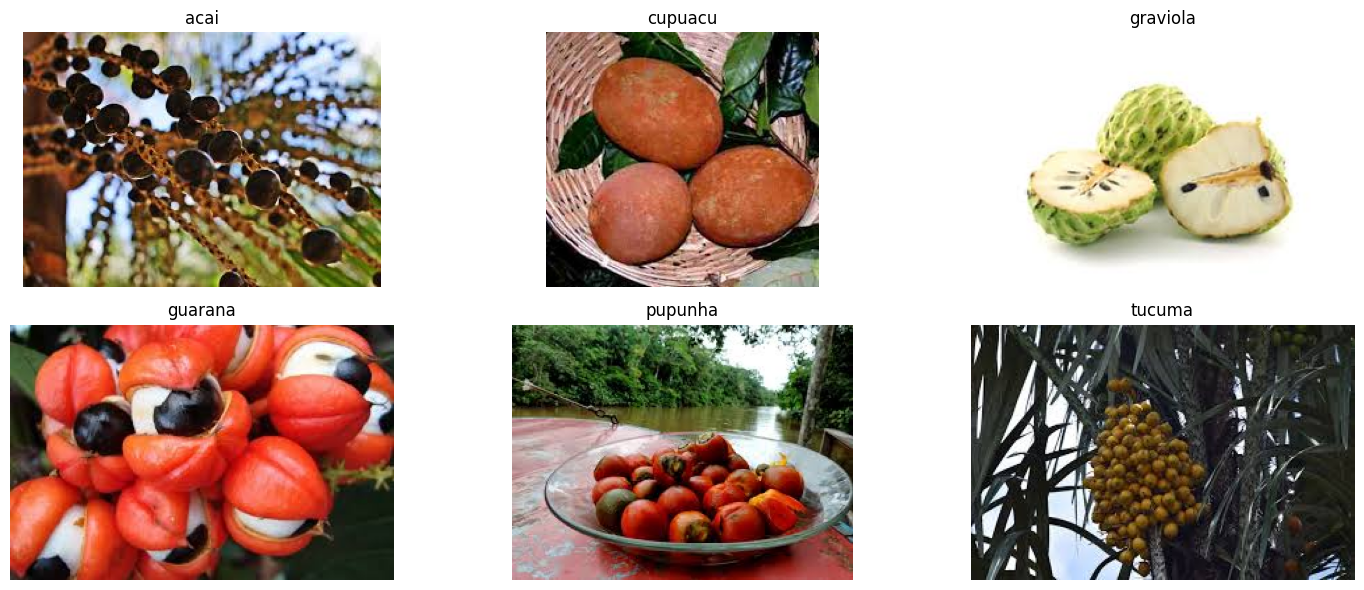

In [1]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

# Path to your dataset
train_dir = "/content/drive/MyDrive/AI/FruitinAmazon/FruitinAmazon/train"  # change this

# Step 1: Get class directories
classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

images = []
titles = []

# Step 2: Select one random image from each class
for cls in classes:
    class_path = os.path.join(train_dir, cls)

    # Get all image files (filter common formats)
    img_files = [f for f in os.listdir(class_path)
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if img_files:
        img_name = random.choice(img_files)
        img_path = os.path.join(class_path, img_name)

        img = Image.open(img_path)
        images.append(img)
        titles.append(cls)

# Step 3: Plot images in grid (2 rows)
num_images = len(images)
cols = (num_images + 1) // 2  # divide into 2 rows

plt.figure(figsize=(15, 6))

for i in range(num_images):
    plt.subplot(2, cols, i + 1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [2]:


corrupted_images = []

# Iterate through each class subdirectory
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            # Try opening and verifying the image
            with Image.open(img_path) as img:
                img.verify()  # checks for corruption

        except (IOError, SyntaxError):
            corrupted_images.append(img_path)

            # Remove corrupted image
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

# Final report
if not corrupted_images:
    print("No Corrupted Images Found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")

No Corrupted Images Found.


In [3]:
from tensorflow.keras import layers

data_augmentation_layers = [
layers.RandomFlip("horizontal"),
layers.RandomRotation(0.1),
layers.RandomZoom(0.1),
    layers.Rescaling(1./255),
]
def data_augmentation(images):
  for layer in data_augmentation_layers:
    images = layer(images)
  return images

In [4]:
import tensorflow as tf
# Define image size and batch size
img_height = 128 # Example image height
img_width = 128 # Example image width
batch_size = 32
validation_split = 0.2 # 80% training, 20% validation
# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255) # Normalize pixel values to [0, 1]
# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
train_dir,
labels='inferred',
label_mode='int',
image_size=(img_height, img_width),
interpolation='nearest',
batch_size=batch_size,
shuffle=True,
validation_split=validation_split,
subset='training',
seed=123
)
# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
train_dir,
labels='inferred',
label_mode='int',
image_size=(img_height, img_width),
interpolation='nearest',
batch_size=batch_size,
shuffle=False,
validation_split=validation_split,
subset='validation',
seed=123
)
# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Set number of classes
num_classes = 6

# Input shape
input_shape = (128, 128, 3)

model = models.Sequential([
layers.Input(shape=(128, 128, 3)),
*data_augmentation_layers, # Include augmentation before the model layers
layers.Conv2D(32, (3,3), activation=None),
layers.BatchNormalization(),
layers.Activation("relu"),
layers.MaxPooling2D(pool_size=(2,2), strides=2),
layers.Dropout(0.25),

layers.Conv2D(32, (3,3), activation=None),
layers.BatchNormalization(),
layers.Activation("relu"),
layers.MaxPooling2D(pool_size=(2,2), strides=2),
layers.Dropout(0.25),

layers.Flatten(),

layers.Dense(64, activation=None),
layers.BatchNormalization(),
layers.Activation("relu"),
layers.Dropout(0.25),

layers.Dense(128, activation=None),
layers.BatchNormalization(),
layers.Activation("relu"),
layers.Dropout(0.25),

#Output layer
layers.Dense(num_classes, activation="softmax")
]) # Initialize an empty Sequential model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 61, 61, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,843,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,863,526 (7.11 MB)

 Trainable params: 1,863,014 (7.11 MB)

 Non-trainable params: 512 (2.00 KB)

In [6]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stopping],
    # batch_size=16
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.1291 - loss: 2.2663
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 929ms/step - accuracy: 0.1528 - loss: 2.1533 - val_accuracy: 0.0000e+00 - val_loss: 1.7789
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 997ms/step - accuracy: 0.3594 - loss: 1.7356
Epoch 2: val_accuracy improved from 0.00000 to 0.16667, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.3750 - loss: 1.7127 - val_accuracy: 0.1667 - val_loss: 1.7501
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.3756 - loss: 1.4849
Epoch 3: val_accuracy did not improve from 0.16667
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 708ms/step - accuracy: 0.3611 - loss: 1.5023 - val_accuracy: 0.1667 - val_loss: 1.7481
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 603ms/step - accuracy: 0.3744 - loss: 1.4097
Epoch 4: val_accuracy did not improve from 0.16667
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 774ms/step - accuracy: 0.3889 - loss: 1.3934 - val_accuracy: 0.1667 - val_loss: 1.7603
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 621ms/step - accuracy: 0.5006 - loss: 1.3566
Epoch 5: val_accuracy did not improve from 0.16667
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 723ms/step - accuracy: 0.4861 - loss: 1.3392 - val_accuracy: 0.1667 - val_loss: 1.7804
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 791ms/step - accuracy: 0.5544 - loss: 1.2243
E

In [7]:
test_loss, test_acc = model.evaluate(val_ds)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.1667 - loss: 1.7481

Test Loss: 1.7481
Test Accuracy: 0.1667


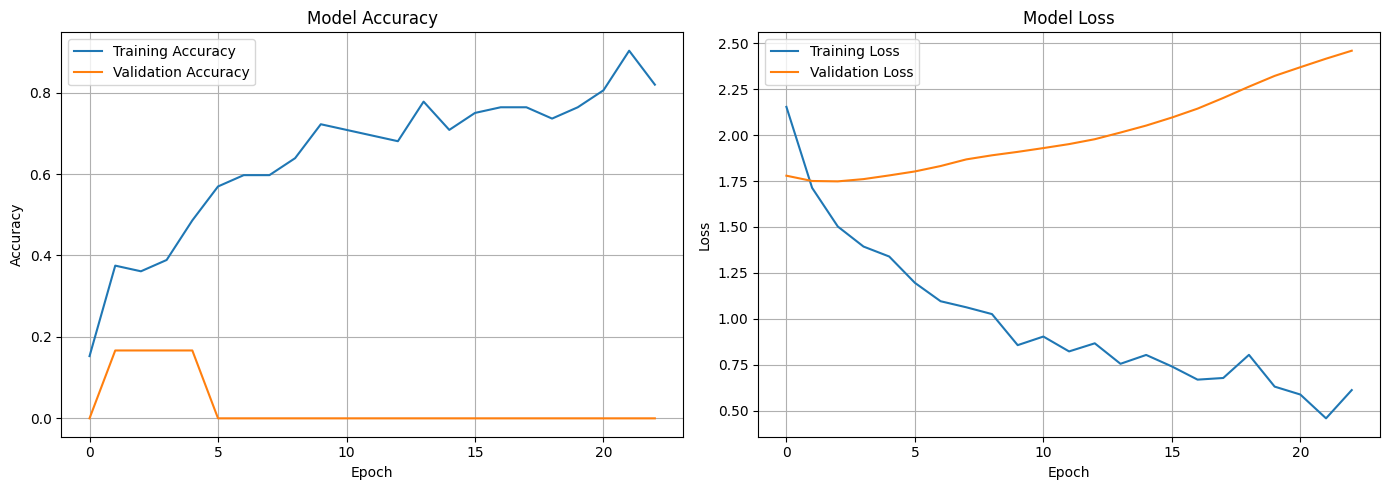

In [8]:
# Plot training history
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [9]:
# Task 6: Save and Load the Model
# Write your code here

# Save the model
model.save('fruit_classifier_cnn.h5')
print("Model saved to 'fruit_classifier_cnn.h5'")

# Load the saved model
loaded_model = tf.keras.models.load_model('fruit_classifier_cnn.h5')
print("Model loaded successfully.")

# Re-evaluate the loaded model
loaded_loss, loaded_acc = loaded_model.evaluate(val_ds)
print(f"\nLoaded Model - Test Loss: {loaded_loss:.4f}")
print(f"Loaded Model - Test Accuracy: {loaded_acc:.4f}")

Model saved to 'fruit_classifier_cnn.h5'


Model loaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step - accuracy: 0.1667 - loss: 1.7481

Loaded Model - Test Loss: 1.7481
Loaded Model - Test Accuracy: 0.1667


In [11]:
import tensorflow as tf

test_dir = "/content/drive/MyDrive/AI/FruitinAmazon/FruitinAmazon/train"

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(128, 128),
    batch_size=16,
    shuffle=False   # VERY IMPORTANT for correct evaluation
)

Found 90 files belonging to 6 classes.


In [12]:
test_ds = test_ds.map(lambda x, y: (x / 255.0, y))

In [13]:
import numpy as np

# Get predictions (probabilities)
predictions = model.predict(test_ds)

# Convert probabilities → class labels
pred_labels = np.argmax(predictions, axis=1)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step


In [14]:
true_labels = []

for images, labels in test_ds:
    true_labels.extend(labels.numpy())

true_labels = np.array(true_labels)

In [15]:
from sklearn.metrics import classification_report

class_names = classes # Use the 'classes' variable that was already extracted

print(classification_report(true_labels, pred_labels, target_names=class_names))

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00        15
     cupuacu       0.00      0.00      0.00        15
    graviola       0.00      0.00      0.00        15
     guarana       0.00      0.00      0.00        15
     pupunha       0.17      1.00      0.29        15
      tucuma       0.00      0.00      0.00        15

    accuracy                           0.17        90
   macro avg       0.03      0.17      0.05        90
weighted avg       0.03      0.17      0.05        90



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
from tensorflow.keras.applications import VGG16
# Load the VGG16 model pre-trained on ImageNet, without the top classification layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [17]:
for layer in base_model.layers:
  layer.trainable = False

In [18]:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
# Add custom layers on top of the pre-trained model
x = base_model.output
x = GlobalAveragePooling2D()(x) # Reduces dimensions (height, width) to a single vector per image
x = Dense(1024, activation='relu')(x) # Fully connected layer with 1024 neurons
x = Dense(6, activation='softmax')(x) # Output layer for 10 classes (with softmax for multi-class classification)

In [19]:
from tensorflow.keras.models import Model
# Create the final model
model = Model(inputs=base_model.input, outputs=x)

In [20]:
from tensorflow.keras.optimizers import Adam
# Compile the model
model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
new_history = model.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stopping],
    # batch_size=16
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2205 - loss: 1.7481
Epoch 1: val_accuracy improved from 0.16667 to 0.55556, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 6s/step - accuracy: 0.2083 - loss: 1.7448 - val_accuracy: 0.5556 - val_loss: 1.3193
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5446 - loss: 1.4113
Epoch 2: val_accuracy did not improve from 0.55556
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.5556 - loss: 1.3813 - val_accuracy: 0.5000 - val_loss: 1.3459
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5179 - loss: 1.2209
Epoch 3: val_accuracy did not improve from 0.55556
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.5694 - loss: 1.1800 - val_accuracy: 0.5556 - val_loss: 1.1371
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7043 - loss: 0.9911
Epoch 4: val_accuracy improved from 0.55556 to 0.66667, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.7222 - loss: 0.9820 - val_accuracy: 0.6667 - val_loss: 0.9325
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8200 - loss: 0.8163
Epoch 5: val_accuracy improved from 0.66667 to 0.72222, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.8194 - loss: 0.8422 - val_accuracy: 0.7222 - val_loss: 0.7944
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8652 - loss: 0.6778
Epoch 6: val_accuracy did not improve from 0.72222
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 7s/step - accuracy: 0.8611 - loss: 0.6914 - val_accuracy: 0.7222 - val_loss: 0.8358
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9149 - loss: 0.6300
Epoch 7: val_accuracy improved from 0.72222 to 0.77778, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 6s/step - accuracy: 0.9167 - loss: 0.6044 - val_accuracy: 0.7778 - val_loss: 0.7319
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9398 - loss: 0.5450
Epoch 8: val_accuracy did not improve from 0.77778
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 6s/step - accuracy: 0.9444 - loss: 0.5161 - val_accuracy: 0.7778 - val_loss: 0.6318
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9196 - loss: 0.4606
Epoch 9: val_accuracy did not improve from 0.77778
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 5s/step - accuracy: 0.9306 - loss: 0.4391 - val_accuracy: 0.7778 - val_loss: 0.6498
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9705 - loss: 0.3787
Epoch 10: val_accuracy did not improve from 0.77778
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.9583 - loss: 0.3944 - val_accuracy: 0.7778 - val_loss: 0.6214
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9653 - loss: 0.3203
Epoch 11: val_a


Epoch 11: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.9583 - loss: 0.3359 - val_accuracy: 0.8333 - val_loss: 0.6049
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9601 - loss: 0.3117
Epoch 12: val_accuracy improved from 0.83333 to 0.94444, saving model to best_model.h5



Epoch 12: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 7s/step - accuracy: 0.9583 - loss: 0.3103 - val_accuracy: 0.9444 - val_loss: 0.4479
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9803 - loss: 0.2644
Epoch 13: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.9722 - loss: 0.2592 - val_accuracy: 0.8889 - val_loss: 0.4318
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9595 - loss: 0.2545
Epoch 14: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 6s/step - accuracy: 0.9722 - loss: 0.2334 - val_accuracy: 0.8889 - val_loss: 0.4707
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9797 - loss: 0.1926
Epoch 15: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 6s/step - accuracy: 0.9861 - loss: 0.1986 - val_accuracy: 0.9444 - val_loss: 0.4625
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 1.0000 - loss: 0.1457  
Epoch 16

In [21]:
test_loss, test_acc = model.evaluate(val_ds)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.9444 - loss: 0.2978

Test Loss: 0.2978
Test Accuracy: 0.9444


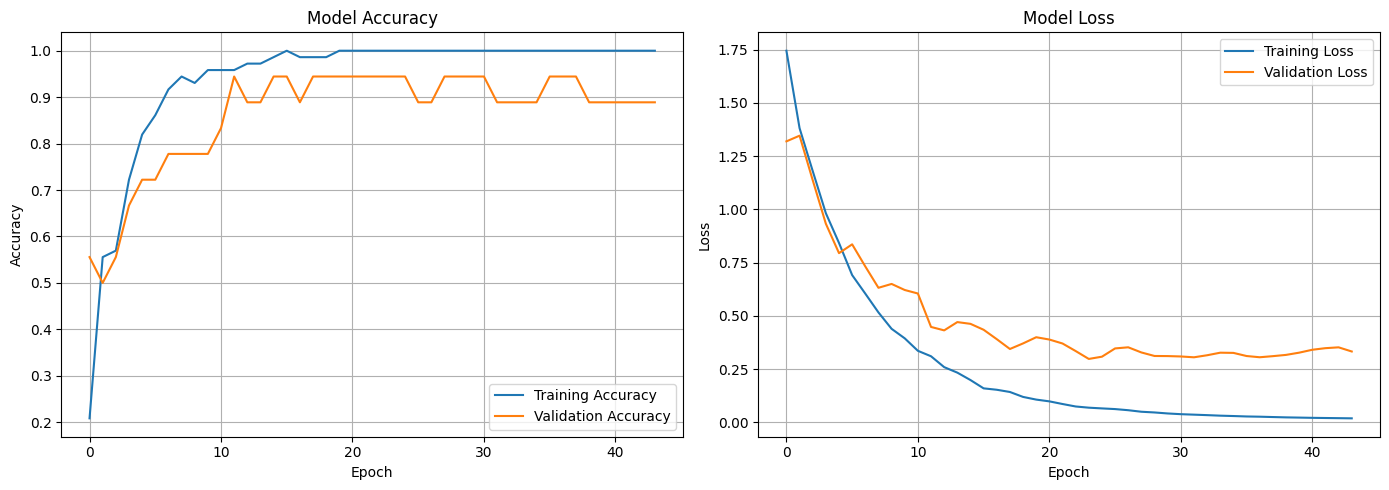

In [22]:
# Plot training history
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(new_history.history['accuracy'], label='Training Accuracy')
ax1.plot(new_history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(new_history.history['loss'], label='Training Loss')
ax2.plot(new_history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [23]:
# Task 6: Save and Load the Model
# Write your code here

# Save the model
model.save('fruit_classifier_cnn.h5')
print("Model saved to 'fruit_classifier_cnn.h5'")

# Load the saved model
loaded_model = tf.keras.models.load_model('fruit_classifier_cnn.h5')
print("Model loaded successfully.")

# Re-evaluate the loaded model
loaded_loss, loaded_acc = loaded_model.evaluate(val_ds)
print(f"\nLoaded Model - Test Loss: {loaded_loss:.4f}")
print(f"Loaded Model - Test Accuracy: {loaded_acc:.4f}")

Model saved to 'fruit_classifier_cnn.h5'


Model loaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.9444 - loss: 0.2978

Loaded Model - Test Loss: 0.2978
Loaded Model - Test Accuracy: 0.9444


In [24]:
import tensorflow as tf

test_dir = "/content/drive/MyDrive/AI/FruitinAmazon/FruitinAmazon/test"

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(128, 128),
    batch_size=16,
    shuffle=False   # VERY IMPORTANT for correct evaluation
)

Found 30 files belonging to 6 classes.


In [25]:
import numpy as np

# Get predictions (probabilities)
predictions = model.predict(test_ds)

# Convert probabilities → class labels
pred_labels = np.argmax(predictions, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step


In [26]:
true_labels = []

for images, labels in test_ds:
    true_labels.extend(labels.numpy())

true_labels = np.array(true_labels)

In [27]:
from sklearn.metrics import classification_report

class_names = classes # Use the 'classes' variable that was already extracted

print(classification_report(true_labels, pred_labels, target_names=class_names))

              precision    recall  f1-score   support

        acai       0.38      1.00      0.56         5
     cupuacu       1.00      0.40      0.57         5
    graviola       1.00      1.00      1.00         5
     guarana       1.00      1.00      1.00         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.40      0.40      0.40         5

    accuracy                           0.63        30
   macro avg       0.63      0.63      0.59        30
weighted avg       0.63      0.63      0.59        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
